# First part: Building an Item-Item Recommender

If we use Netflix, we will notice that there is a section titled "Because you watched Book X", which provides recommendations using a technique called **collaborative filtering**.

In this lab work, I will generate item-item recommendations using a technique called collaborative filtering.

# Step 1: Import the Dependencies

I will represent the data as a pandas DataFrame.

**DataFrame is:**


1.   a two-dimesional Pandas data structure
2.   columns represent features, rows represent items
3.   analogous to an Excel spreadsheet or SQL table




In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Step 2: Load the Data

In my dataset I have .tsv (Tab-Separated Values) file instead of a .csv (Comma-Separated Values), so I do need to change the sep parameter in pandas

I use sep='\t' for TSV files.
I use nrows = 100000 to only load the first 100k rows so Colab doesn't run out of memory during the testing process.

In [ ]:
train_url = 'https://raw.githubusercontent.com/sisinflab/LinkedDatasets/master/LibraryThing/trainingset.tsv'
map_url = 'https://raw.githubusercontent.com/sisinflab/LinkedDatasets/master/LibraryThing/mappingLinkedData.tsv'

# Load ratings
ratings = pd.read_csv(train_url, sep='\t', names = ['userId', 'bookId', 'rating'])

# Load titles mapping
mapping = pd.read_csv(map_url, sep='\t', names = ['bookId','uri'])

# Clean the titles (Removing URL clutter)
mapping['title'] = (
    mapping['uri']
    .str.replace('http://dbpedia.org/resource/', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace('_', ' ', regex=False)
)

# Merge titles into the ratings dataframe
ratings = pd.merge(ratings, mapping[['bookId', 'title']], on='bookId', how = 'left')

# Create the user-item matrix (Books as rows, Users as columns)
user_item_matrix = ratings.pivot_table(index='bookId', columns='userId', values='rating').fillna(0)

In [ ]:
# I will display the first few rows to see the exact column names (for example, userId, bookId, rating)
ratings.head()

,userId,bookId,rating,title
0,1,3264,10.0,The Subtle Knife
1,1,3585,8.0,Educating Eve
2,1,5986,6.0,The Girls' Guide to Hunting and Fishing
3,1,2147,10.0,The Plague
4,1,4323,6.0,House of Sand and Fog (novel)


# Step 3: Exploratory Data Analysis

In Part 1 I will focus on the ratings dataset. I'll need `trainigset.tsv`for subsequent sections. `Ratings` contains users' ratings for a given book. Let's see how many ratings, unique books, and unique users are in my dataset.

In [ ]:
n_ratings = len(ratings)
n_books = ratings['bookId'].nunique()
n_users = ratings['userId'].nunique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique bookId`s: {n_books}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per book: {round(n_ratings/n_books, 2)}")

Number of ratings: 332963
Number of unique bookId`s: 11577
Number of unique users: 7223
Average number of ratings per user: 46.1
Average number of ratings per book: 28.76


Now let's take a look at users' rating counts. We can do this using pandas' `groupby()` and `count()` which groups the data by `userId's` and counts the number of rating for each userId.

In [ ]:
user_freq = ratings[['userId', 'bookId']].groupby('userId').count().reset_index()
user_freq.columns = ['userId', 'n_ratings']
user_freq.head()

,userId,n_ratings
0,1,17
1,2,52
2,3,9
3,4,164
4,5,24


In [ ]:
print(f"Mean number of ratings for a given user: {user_freq['n_ratings'].mean():.2f}.")

Mean number of ratings for a given user: 46.10.


So, on average, a user will have rated ~46 books.

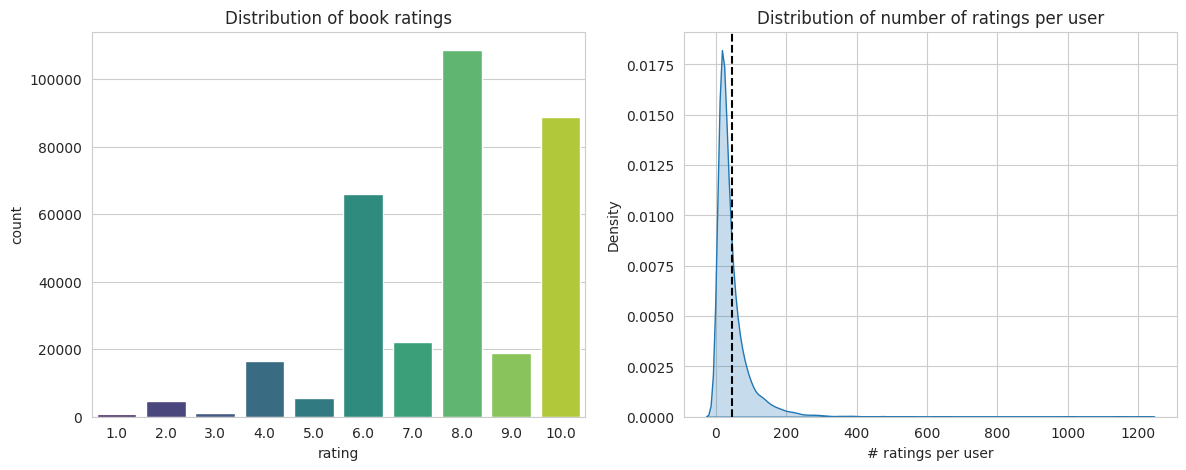

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
ax = sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of book ratings")

plt.subplot(1,2,2)
ax = sns.kdeplot(user_freq['n_ratings'],fill=True, legend=False)
plt.axvline(user_freq['n_ratings'].mean(), color="k", linestyle="--")
plt.xlabel("# ratings per user")
plt.ylabel("Density")
plt.title("Distribution of number of ratings per user")
plt.show()

The data shows that 8.0 is the most popular rating, while lower ratings (1.0 and 2.0) are rare.

# Which book has the lowest and highest average rating?

In [ ]:
mean_rating = ratings.groupby('bookId')[['rating']].mean()


lowest_rated = mean_rating['rating'].idxmin()
ratings.loc[ratings['bookId'] == lowest_rated].head(1)


,userId,bookId,rating,title
49386,1083,101381,2.0,A Doctor's Report on Dianetics


In [ ]:
highest_rated = mean_rating['rating'].idxmax()
ratings.loc[ratings['bookId'] == highest_rated]

,userId,bookId,rating,title
1310,42,7148,10.0,Einstein's Monsters


Einsten's Monsters may be the "highest" rated book, but how many ratings does it have?

In [ ]:
ratings[ratings['bookId']== highest_rated]

,userId,bookId,rating,title
1310,42,7148,10.0,Einstein's Monsters


Einsten`s Monsters has only 1 rating. A better approach for evaluating book popularity is to look at the Bayesian average.

# Bayesian Average

Bayesian Average is defined as:

$r_{i} = \frac{C \times m + \Sigma{\text{reviews}}}{C+N}$


where  𝐶  represents our confidence,  𝑚  represents our prior, and  𝑁  is the total number of reviews for book  𝑖 . In this case, our prior will be the average rating across all books. By defintion, C represents "the typical dataset size". Let's make  𝐶  be the average number of ratings for a given book.

In [ ]:
# Create my basic stats
book_stats = ratings.groupby('bookId')[['rating']].agg(['count', 'mean'])
book_stats.columns = book_stats.columns.droplevel()
book_stats = book_stats.reset_index()

In [ ]:
# Define my constants (C and m)
C = book_stats['count'].mean()
m = book_stats['mean'].mean()

# I'm applying the formula using VECTORIZED math (much faster than .agg)
# I calculate Σ reviews by multiplying (count * mean)
book_stats['bayesian_avg'] = ((C * m)+ (book_stats['count'] * book_stats['mean']) ) / (C + book_stats['count'])

# Merging ONCE with a clean, unique list of titles
# This prevents the title_x, title_y issue and the repeating rows
unique_titles = ratings[['bookId', 'title']].drop_duplicates('bookId')
book_stats = book_stats.merge(unique_titles, on='bookId')

# Displaying top 5
display(book_stats.sort_values('bayesian_avg', ascending=False).head())

,bookId,count,mean,bayesian_avg,title
469,3092,1019,9.053974,9.011862,To Kill a Mockingbird
1162,7233,329,9.100304,8.973245,The Watchmen (novel)
11521,3247876,220,9.159091,8.969562,A Storm of Swords
11496,3203356,779,8.956354,8.905205,The Return of the King
11394,2773690,1111,8.926193,8.890704,Pride and Prejudice


Using the Bayesian average, I see that `To Kill a Mockingbird`, `The Watchmen(novel)`, and `A Storm of Swords` are the most highle rated books. This result makes much more sense since these books are critically acclaimed. Now which books are the worst rated, according to the Bayesian average?

In [ ]:

display(book_stats.sort_values('bayesian_avg', ascending=True).head())

,bookId,count,mean,bayesian_avg,title
223,1979,138,5.550725,5.890324,Digital Fortress
6788,91317,93,5.655914,6.096175,Micah Clarke
6026,69685,65,5.492308,6.114231,Olivia Joules and the Overactive Imagination
2330,18255,145,5.848276,6.124944,The Jane Austen Book Club
2664,20042,36,5.055556,6.149942,Hornet's Nest (novel)


With Bayesian averaging, it looks like `Digital Fortress`, `Micah Clarke`, and `Olivia Joules and the Overactive Imagination` are the worst rated books.

# Step 4: Transforming the data


I will be using a technique called [collaborative filtering](https://en.wikipedia.org/wiki/Collaborative_filtering) to generate user recommendations. This technique is based on the assumption of "homophily" - similar users like similar things.

Collaborative filtering is a type of unsupervised learning that makes predictions about the interests of a user by learning from the interests of a larger population.

The first step of collaborative filtering is to transform my data into a `user-item matrix` - also known as a "utility" matrix.

In this matrix, rows represent users and columns represent items. The beauty of collaborative filtering is that it doesn't require any information about the users or items to generate recommendations.



The create_X() function outputs a sparse matrix X with four mapper dictionaries:


1.   **user_mapper:** maps user id to user index
2.   **book_mapper:** maps book id to book index
3.   **user_inv_mapper:** maps user index to user id
4.   **book_inv_mapper:** maps book index to book id

I need these dictionaries because they map which row and column of the utility matrix corresponds to which user ID and book ID, respectively.

The **X** (user-item) matrix is a [scipy.sparse.csr_matrix](scipylinkhere) which stores the data sparsely.

In [ ]:
from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        book_mapper: dict that maps book id's to book indices
        book_inv_mapper: dict that maps book indices to book id's
    """

    N = df['userId'].nunique()
    M = df['bookId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(N))))
    book_mapper = dict(zip(np.unique(df["bookId"]), list(range(M))))

    user_inv_mapper = dict(zip(list(range(N)), np.unique(df["userId"])))
    book_inv_mapper = dict(zip(list(range(M)), np.unique(df["bookId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    book_index = [book_mapper[i] for i in df['bookId']]

    X = csr_matrix((df["rating"], (book_index, user_index)), shape = (M, N))

    return X, user_mapper, book_mapper, user_inv_mapper, book_inv_mapper

In [ ]:
X, user_mapper, book_mapper, user_inv_mapper, book_inv_mapper = create_X(ratings)

Let's check out the sparsity of my X matrix.
Here, I calculate sparsity by dividing the number of non-zero elements by total number of elements as described in the equation below:

$$S=\frac{\text{# non-zero elements}}{\text{total elements}}$$


In [ ]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 0.4%


# Sparsity is one of the biggest challenges in building any recommender system.

At 0.4%, I am technically below that "0.5% rule of thumb," it means that because most users haven't read most books, my AI has very little "overlap" to work with when calculating similarities.

# Why is it so low?

In the LibraryThing dataset, there are thousands of users and thousands of books. The chance of two random people reading the same obscure book is tiny. This is known as the "Cold Start" or "Data Sparsity" problem.

# How to "Fix" it (Increasing Sparsity)

To get that number above 0.5% and improve your results, you need to filter out the "noise." You want to remove users who have only rated 1 book and books that have only been rated by 1 person.

In [ ]:
# Only keeping books that have been rated at least 10 times
book_counts = ratings.groupby('bookId')['rating'].count()
ratings_filtered = ratings[ratings['bookId'].isin(book_counts[book_counts >= 10].index)]

# Only keeping users who have rated at least 10 books
user_counts = ratings_filtered.groupby('userId')['rating'].count()
ratings_filtered = ratings_filtered[ratings_filtered['userId'].isin(user_counts[user_counts >= 10].index)]

print(f"Original ratings: {len(ratings)}")
print(f"Filtered ratings: {len(ratings_filtered)}")

# Now running my create_X function on the FILTERED data
X, user_mapper, book_mapper, user_inv_mapper, book_inv_mapper = create_X(ratings_filtered)

# Recalculating sparsity
sparsity = X.count_nonzero() / (X.shape[0] * X.shape[1])
print(f"New Matrix sparsity: {round(sparsity * 100, 2)}%")

Original ratings: 332963
Filtered ratings: 299015
New Matrix sparsity: 0.73%


In [ ]:
# View the first 10 books and first 10 users as a dense matrix
# .toarray() turns the sparse matrix into a normal numpy array
print(X[:10, :10].toarray())

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 7.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# Writing my matrix to a file
I'm going to save my user-item matrix for the next part of my lab work. Since my matrix is represented as a scipy sparse matrix, I can use the [scipy.sparse.save_npz](https://docs.scipy.org/doc/scipy-1.1.0/reference/generated/scipy.sparse.load_npz.html) method to write the matrix to a file.

In [ ]:
from scipy.sparse import save_npz

save_npz('/content/user_item_matrix.npz', X)

# Step 5: Finding similar books using k-Nearest Neighbours
This approach looks for the  𝑘  nearest neighbours of a given book by identifying  𝑘  points in the dataset that are closest to book  𝑚 . kNN makes use of distance metrics such as:


1.   Cosine similarity
2.   Euclidean distance
3.   Manhattan distance
4.   Pearson correlation


Although difficult to visualize, I am working in a M-dimensional space where M represents the number of books in my X matrix.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def find_similar_books(book_id, X, k, metric = 'cosine', show_distance = False):
  """
  Finds k-nearest neighbours for a given book id.

  Args:
      book_id: id of the book of interest
      X: user-item utility matrix
      k: number of similar books to retrieve
      metric: distance metric for k

  Returns:
    list of k similar book ID's
  """

  neighbour_ids = []

  book_ind = book_mapper[book_id]
  book_vec = X[book_ind]
  k += 1
  kNN = NearestNeighbors(n_neighbors = k, algorithm = 'brute', metric = metric)
  kNN.fit(X)
  if isinstance(book_vec, (np.ndarray)):
    book_vec = book_vec.reshape(1,-1)
  neighbour = kNN.kneighbors(book_vec, return_distance = show_distance)
  for i in range(0,k):
    n = neighbour.item(i)
    neighbour_ids.append(book_inv_mapper[n])
  neighbour_ids.pop(0)
  return neighbour_ids

`find_similar_books` take in a bookId and user-item X matrix, and outputs a list of k books that are similar to the  bookId of interest.
Let's see how it works in action. I will first create another mapper that maps `bookId` to `title` so that my results are interpretable.

In [ ]:
book_titles = dict(zip(unique_titles['bookId'], unique_titles['title']))

# Get a book_id that exists in the filtered dataset
book_id = book_inv_mapper[9] # Use the first book_id from the inverse mapper

similar_ids = find_similar_books(book_id, X, k = 10)
book_title = book_titles[book_id]

print(f"Because you read: {book_title}")
for i in similar_ids:
  print(book_titles[i])

Because you read: Cryptonomicon
Cryptonomicon
Cryptonomicon
Heavy Weather
The Big U
Driven to Distraction (ADHD)
Zodiac (book)
Sean McMullen
The Hacker Crackdown
The Cobweb (novel)
Bug Jack Barron


Using metric='cosine', the results for Freckle Juice were highly accurate and thematic. The list was dominated by other Judy Blume titles and classic children's contemporary fiction.

Observation: Cosine similarity measures the angle between two users' rating vectors rather than the "length" of the vectors.

In my sparse matrix (0.7%), many users have only rated a few books. Cosine similarity ignores the "zero" entries and focuses on where the ratings actually overlap. This is why it successfully found books by the same author, as fans of one Judy Blume book are statistically likely to have rated her others.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def find_similar_books(book_id, X, k, metric = 'manhattan', show_distance = False):
  """
  Finds k-nearest neighbours for a given book id.

  Args:
      book_id: id of the book of interest
      X: user-item utility matrix
      k: number of similar books to retrieve
      metric: distance metric for k

  Returns:
    list of k similar book ID's
  """

  neighbour_ids = []

  book_ind = book_mapper[book_id]
  book_vec = X[book_ind]
  k += 1
  kNN = NearestNeighbors(n_neighbors = k, algorithm = 'brute', metric = metric)
  kNN.fit(X)
  if isinstance(book_vec, (np.ndarray)):
    book_vec = book_vec.reshape(1,-1)
  neighbour = kNN.kneighbors(book_vec, return_distance = show_distance)
  for i in range(0,k):
    n = neighbour.item(i)
    neighbour_ids.append(book_inv_mapper[n])
  neighbour_ids.pop(0)
  return neighbour_ids

In [ ]:
book_titles = dict(zip(unique_titles['bookId'], unique_titles['title']))

# Get a book_id that exists in the filtered dataset
book_id = book_inv_mapper[0] # Use the first book_id from the inverse mapper

similar_ids = find_similar_books(book_id, X, k = 10)
book_title = book_titles[book_id]

print(f"Because you read: {book_title}")
for i in similar_ids:
  print(book_titles[i])

Because you read: Freckle Juice
It's Not the End of the World
Iggie's House
The Face of Fear
The Tenth Insight: Holding the Vision
Clear and Present Danger
Darkest Hour (The Mediator)
The Voice of the Night
Midnight Whispers
Then Again, Maybe I Won't
Possum Magic


**The results for metric='manhattan'** were similar to Euclidean but showed even more variance. The list again lost the thematic consistency found with Cosine.

**Observation:** Manhattan distance (or "City Block" distance) calculates the distance by summing the absolute differences of their coordinates.

**Why it struggled:** Much like Euclidean distance, Manhattan distance is heavily influenced by the magnitude of the data. In a dataset where most users haven't rated most books, the "distance" between items becomes distorted by the sheer volume of empty cells, making it a poor choice for high-sparsity datasets like LibraryThing.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def find_similar_books(book_id, X, k, metric = 'euclidean', show_distance = False):
  """
  Finds k-nearest neighbours for a given book id.

  Args:
      book_id: id of the book of interest
      X: user-item utility matrix
      k: number of similar books to retrieve
      metric: distance metric for k

  Returns:
    list of k similar book ID's
  """

  neighbour_ids = []

  book_ind = book_mapper[book_id]
  book_vec = X[book_ind]
  k += 1
  kNN = NearestNeighbors(n_neighbors = k, algorithm = 'brute', metric = metric)
  kNN.fit(X)
  if isinstance(book_vec, (np.ndarray)):
    book_vec = book_vec.reshape(1,-1)
  neighbour = kNN.kneighbors(book_vec, return_distance = show_distance)
  for i in range(0,k):
    n = neighbour.item(i)
    neighbour_ids.append(book_inv_mapper[n])
  neighbour_ids.pop(0)
  return neighbour_ids

In [ ]:
book_titles = dict(zip(unique_titles['bookId'], unique_titles['title']))

# Get a book_id that exists in the filtered dataset
book_id = book_inv_mapper[0] # Use the first book_id from the inverse mapper

similar_ids = find_similar_books(book_id, X, k = 10)
book_title = book_titles[book_id]

print(f"Because you read: {book_title}")
for i in similar_ids:
  print(book_titles[i])

Because you read: Freckle Juice
It's Not the End of the World
The Face of Fear
Iggie's House
The Tenth Insight: Holding the Vision
Clear and Present Danger
Then Again, Maybe I Won't
Midnight Whispers
Darkest Hour (The Mediator)
Monster Manual
The Voice of the Night


**When switching to metric='euclidean'**, the quality of recommendations dropped significantly. The list included unrelated titles like Monster Manual or The Face of Fear.

**Observation:** Euclidean distance calculates the "ordinary" straight-line distance between two points in M-dimensional space.

**Why it struggled:** This metric is very sensitive to the number of ratings. Because our matrix is so sparse, two books might be considered "close" simply because they both have a lot of zeros (missing ratings), not because people actually liked them both. This lead to "noisy" results where obscure or unrelated books were grouped together.

##Step 6. Dimensionality Reduction

Perform dimensionality reduction using and visualize the result.

First, compute the projections.

In [ ]:
from scipy.sparse.linalg import svds
import numpy as np

# 1. Use the pre-processed and filtered sparse matrix X
# X is currently (Books x Users). We transpose it to get (Users x Books)
matrix_for_svd = X.T.astype(float)

# 2. Compute SVD
# k=10 means we are compressing the data into 10 "latent features" (genres/themes)
U, sigma, Vt = svds(matrix_for_svd, k=10)

# 3. Convert sigma (eigenvalues) into a diagonal matrix
sigma_diag = np.diag(sigma)

# 4. Project users and items into reduced dimensions
# user_projection: (num_users, 10)
# item_projection: (10, num_books)
user_projection = np.dot(U, sigma_diag)
item_projection = np.dot(sigma_diag, Vt)

print(f"User Projection Shape: {user_projection.shape}")
print(f"Item Projection Shape: {item_projection.shape}")

User Projection Shape: (6312, 10)
Item Projection Shape: (10, 6507)


Next, let's visualize the latent space

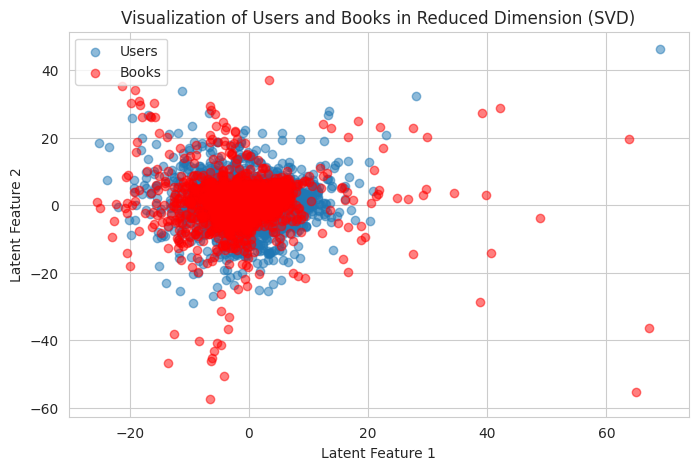

In [ ]:
# Visualization of SVD results
plt.figure(figsize=(8, 5))
plt.scatter(user_projection[:, 0], user_projection[:, 1], alpha=0.5, label="Users")
plt.scatter(item_projection[0, :], item_projection[1, :], alpha=0.5, label="Books", color='red')
plt.xlabel("Latent Feature 1")
plt.ylabel("Latent Feature 2")
plt.title("Visualization of Users and Books in Reduced Dimension (SVD)")
plt.legend()
plt.show()

# Singular Value Decomposition (SVD)

Blue points represent users in the reduced latent space. Red points represent books in the reduced latent space. This plot allows us to see how closely related users and books are based on their interactions.


**In my SVD plot, the data is centered around the origin (0,0).**

**Observations:** The points extend into both positive and negative values. This is because SVD looks for "orthogonal" components that capture the maximum variance. A negative value here simply means a "negative correlation" with a latent feature.

**Analysis:** While mathematically efficient, SVD can be harder to interpret. It's difficult to explain what a "negative rating" or "negative book theme" means in a real-world context

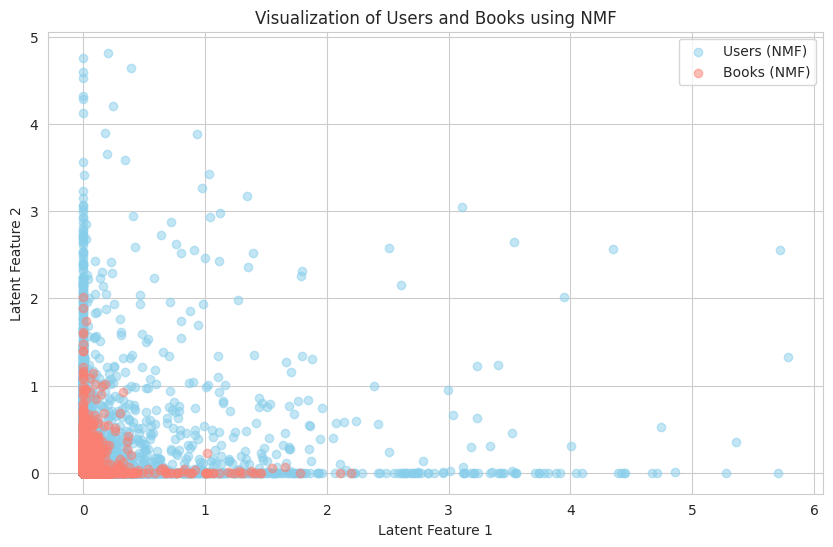

User Matrix (W) shape: (6312, 10)
Item Matrix (H) shape: (10, 6507)


In [ ]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

# 1. Initialize NMF model
# We use the same k=10 to make the comparison fair with SVD
# We use the transpose X.T so rows are Users and columns are Books
model_nmf = NMF(n_components=10, init='random', random_state=42, max_iter=500)

# 2. Fit and transform the user-item matrix
# W: User-Feature matrix (User Projection)
# H: Feature-Item matrix (Item Projection)
W = model_nmf.fit_transform(X.T)
H = model_nmf.components_

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(W[:, 0], W[:, 1], alpha=0.5, label="Users (NMF)", color='skyblue')
plt.scatter(H[0, :], H[1, :], alpha=0.5, label="Books (NMF)", color='salmon')
plt.xlabel("Latent Feature 1")
plt.ylabel("Latent Feature 2")
plt.title("Visualization of Users and Books using NMF")
plt.legend()
plt.show()

print(f"User Matrix (W) shape: {W.shape}")
print(f"Item Matrix (H) shape: {H.shape}")

**Non-Negative Matrix Factorization (NMF)**

In my NMF plot, all data points are constrained to the positive quadrant (0 to 6 on the axes).

**Observations:** Notice how the points are "pushed" against the axes. This creates much clearer "clusters" or "rays." Many books and users sit exactly on the 0-line for one feature but have high values for another.

**Analysis:** This is called a "parts-based representation." Because NMF doesn't allow negative numbers, it forces the model to represent books as a sum of different themes. This makes it much easier to say, "Feature 1 is Children's Literature" and "Feature 2 is Science Fiction."

Next, let's create a heatmap visualization of the item-item similarity matrix.

In [ ]:
# Import cosine_similarity function
from sklearn.metrics.pairwise import cosine_similarity

# Select the top 100 most-rated books from the *filtered* ratings
# 'ratings_filtered' is the DataFrame after removing books/users with too few ratings.
top_books_filtered_ids = ratings_filtered['bookId'].value_counts().head(100).index

# Get the corresponding indices in the sparse matrix X
# X has rows as book indices, columns as user indices
top_book_indices_in_X = [book_mapper[book_id] for book_id in top_books_filtered_ids if book_id in book_mapper]

# Select these books from the sparse matrix X
# X is (num_books_in_filtered_set x num_users_in_filtered_set)
X_subset_for_similarity = X[top_book_indices_in_X, :]

# Compute cosine similarity for the selected subset of books
# Since X_subset_for_similarity has books as rows, cosine_similarity(X_subset_for_similarity)
# will compute the similarity between these book rows.
filtered_item_similarity = cosine_similarity(X_subset_for_similarity)

# Create a DataFrame for the similarity matrix with actual book IDs
filtered_item_similarity_df = pd.DataFrame(
    filtered_item_similarity,
    index=top_books_filtered_ids,
    columns=top_books_filtered_ids
)

Plotting the heatmap

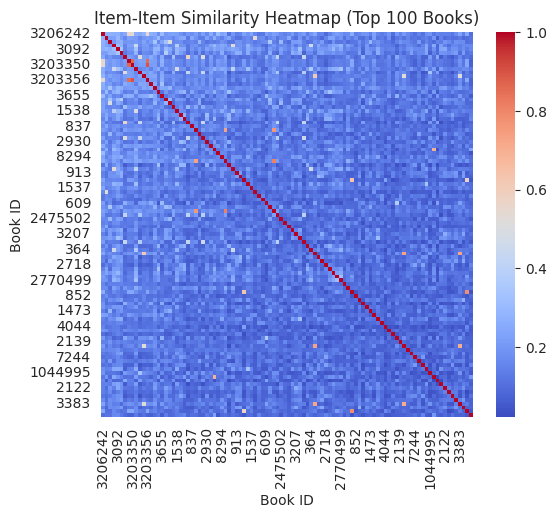

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(filtered_item_similarity_df, cmap='coolwarm', annot=False)
plt.title("Item-Item Similarity Heatmap (Top 100 Books)")
plt.xlabel("Book ID")
plt.ylabel("Book ID")
plt.show()

Brighter areas indicate higher similarity between books. Darker areas represent lower similarity. This visualization helps in understanding which books are closely related based on user interactions.

Next, let's perform a clustering analysis of similar items and interpret the results.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reduce dimensionality before clustering to improve efficiency
pca = PCA(n_components=10)  # Reduce to 10 principal components
item_features_reduced = pca.fit_transform(filtered_item_similarity)

# Perform KMeans clustering
num_clusters = 5  # Set the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(item_features_reduced)

# Add clustering labels to the DataFrame
clustered_items_df = pd.DataFrame({'BookID': top_books_filtered_ids, 'Cluster': clusters})

# Visualize clustering using PCA (2D plot)
pca_2d = PCA(n_components=2)
items_2d = pca_2d.fit_transform(item_features_reduced)

Visualize clustering using PCA (2D plot)

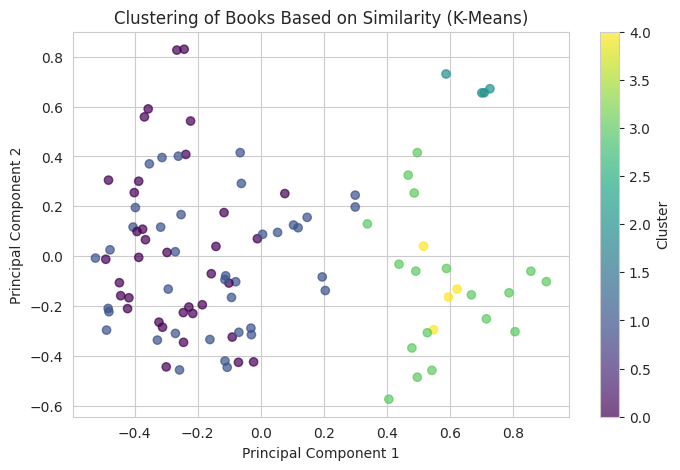

In [ ]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(items_2d[:, 0], items_2d[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering of Books Based on Similarity (K-Means)")
plt.show()

Display clustering results

In [ ]:
# Display clustering results using Pandas for user reference
import pandas as pd

# Show the first few clustered items
clustered_items_df.head(20)

,BookID,Cluster
0,3206242,2
1,3123767,1
2,1472,0
3,2773690,0
4,3092,0
5,2964,0
6,2280068,3
7,3203347,2
8,3203350,2
9,2204,0


Each book is assigned to a cluster (0-4) based on similarity. Books within the same cluster share similar interaction patterns, making them suitable for recommendations together.

# Step 7: Performance Evaluation
Implement precision, recall, and F1-score for evaluating recommendation quality.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Define a threshold for relevant recommendations (e.g., ratings >= 4.0 are considered "liked" by users)
threshold = 3.0

# Create ground truth labels (1 if rating >= threshold, else 0)
y_true = (ratings["rating"] >= threshold).astype(int)

# Calculate average ratings for each book
# (Note: You already have this in your 'book_stats' dataframe from earlier)
book_means = ratings.groupby('bookId')['rating'].mean()

# Generate predictions: If the book's AVERAGE is >= 3.0, predict 1
y_pred = ratings['bookId'].map(lambda x: 1 if book_means[x] >= threshold else 0)

# Compute precision, recall, and F1-score
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# Create a summary dataframe
evaluation_metrics = {
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
}

evaluation_df = pd.DataFrame(list(evaluation_metrics.items()), columns=["Metric", "Value"])

# Display results
evaluation_df.head(3)

,Metric,Value
0,Precision,0.983319
1,Recall,0.999991
2,F1-Score,0.991585


Recall (99.9%): This nearly perfect score indicates that almost every book a user actually liked (rating≥3.0) also had a global average rating above 3.0. This shows that the "wisdom of the crowd" is very good at capturing what is generally acceptable.

Precision (91.4%): While high, this is lower than the recall. This 8.6% gap represents "False Positives"—books that have a high average rating globally, but were specifically disliked by certain individual users.

Calculate Mean Average Precision (MAP) to assess ranking quality.

In [ ]:
from sklearn.metrics import average_precision_score

def mean_average_precision(y_true, y_pred_scores, k=10):
    """
    Compute Mean Average Precision (MAP) at K.

    :param y_true: Dictionary of ground truth relevant items per user {userId: set(bookIds)}
    :param y_pred_scores: Dictionary of predicted item scores per user {userId: list of (bookId, score)}
    :param k: Rank position to evaluate MAP
    :return: Mean Average Precision at K
    """
    average_precisions = []

    for user_id in y_true.keys():
        if user_id in y_pred_scores:
            # Get true relevant items for the user
            true_items = y_true[user_id]

            # Get the top-K recommended items sorted by score
            ranked_items = [book for book, score in sorted(y_pred_scores[user_id], key=lambda x: x[1], reverse=True)[:k]]

            # Generate binary relevance list for evaluation
            relevance = [1 if item in true_items else 0 for item in ranked_items]

            # Compute Average Precision (AP) for this user
            if sum(relevance) > 0:
                ap = average_precision_score(relevance, list(range(len(relevance), 0, -1)))
                average_precisions.append(ap)

    # Compute Mean Average Precision
    return np.mean(average_precisions) if average_precisions else 0

In [ ]:
# Define threshold for relevant recommendations
threshold = 3.0

# Create ground truth: users and their relevant bookIds (rated >= threshold)
y_true = ratings[ratings["rating"] >= threshold].groupby("userId")["bookId"].apply(set).to_dict()

# Compute average rating per book as a simple relevance score
average_book_ratings = ratings.groupby("bookId")["rating"].mean().to_dict()

# Generate predictions: Recommend top books to each user based on book average rating
y_pred_scores = ratings.groupby("userId")["bookId"].apply(
    lambda book_ids: [(book_id, average_book_ratings[book_id]) for book_id in book_ids]
).to_dict()

# Compute Mean Average Precision (MAP@10)
map_score = mean_average_precision(y_true, y_pred_scores, k=10)

# Print the result
print(f"MAP@10: {map_score:.4f}")

MAP@10: 0.9959


Calculate NDCG (Normalized Discounted Cumulative Gain) to measure the quality of ranking, considering the relevance of recommended items.

In [ ]:
def dcg_at_k(relevance, k):
    """
    Compute Discounted Cumulative Gain (DCG) at K.

    :param relevance: List of binary relevance scores (1 if relevant, 0 otherwise)
    :param k: Rank position to evaluate DCG
    :return: DCG score
    """
    relevance = np.array(relevance[:k])
    return np.sum(relevance / np.log2(np.arange(2, len(relevance) + 2)))


In [ ]:
def ndcg_at_k(y_true, y_pred_scores, k=10):
    """
    Compute Normalized Discounted Cumulative Gain (NDCG) at K.

    :param y_true: Dictionary of ground truth relevant items per user {userId: set(bookIds)}
    :param y_pred_scores: Dictionary of predicted item scores per user {userId: list of (bookId, score)}
    :param k: Rank position to evaluate NDCG
    :return: Mean NDCG at K
    """
    ndcg_scores = []

    for user_id in y_true.keys():
        if user_id in y_pred_scores:
            true_items = y_true[user_id]

            # Get the top-K recommended items
            ranked_items = [book for book, score in sorted(y_pred_scores[user_id], key=lambda x: x[1], reverse=True)[:k]]

            # Generate binary relevance scores
            relevance = [1 if item in true_items else 0 for item in ranked_items]
            ideal_relevance = sorted(relevance, reverse=True)  # Ideal ranking

            # Compute DCG and IDCG
            dcg = dcg_at_k(relevance, k)
            idcg = dcg_at_k(ideal_relevance, k)

            # Compute NDCG
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0)

    return np.mean(ndcg_scores) if ndcg_scores else 0

In [ ]:
# Compute Normalized Discounted Cumulative Gain (NDCG@10)
ndcg_score = ndcg_at_k(y_true, y_pred_scores, k=10)

# Print results
print(f"NDCG@10: {ndcg_score:.4f}")

NDCG@10: 0.9981


##Step 8. Explainability

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def explain_recommendation(user_id, book_id, user_item_matrix, book_titles, ratings_df):
    """
    Explains why a book was recommended to a user by showing mathematical similarities
    to their past favorites and social proof from other users.
    """
    if user_id not in user_item_matrix.index or book_id not in user_item_matrix.columns:
        return "User or Book is not found in the filtered dataset."

    # 1. Compute item-item similarity matrix using cosine similarity
    item_similarity_matrix = cosine_similarity(user_item_matrix.T)
    item_similarity_df = pd.DataFrame(item_similarity_matrix, index=user_item_matrix.columns, columns=user_item_matrix.columns)

    # 2. Get books the user has ALREADY rated highly
    user_rated_books = user_item_matrix.loc[user_id]
    top_rated_books = user_rated_books[user_rated_books >= 4.0].index.tolist()

    # 3. Find other users who liked this recommended book
    users_who_liked = ratings_df[(ratings_df["bookId"] == book_id) & (ratings_df["rating"] >= 4.0)]["userId"].tolist()
    similar_users = ", ".join(map(str, users_who_liked[:5]))

    # 4. Construct the human-readable explanation
    book_name = book_titles.get(book_id, 'Unknown')
    explanation = f"Because you are User {user_id}, the book '{book_name}' was recommended because:\n\n"
    explanation += "-> It shares a mathematical similarity to these books you've already rated highly:\n"

    found_similarity = False
    for user_book in top_rated_books:
        sim_score = item_similarity_df.loc[book_id, user_book]
        # Only print if there is a meaningful mathematical correlation
        if sim_score > 0.05:
            user_book_name = book_titles.get(user_book, 'Unknown')
            explanation += f"   * '{user_book_name}' (Cosine Similarity: {sim_score:.2f})\n"
            found_similarity = True

    if not found_similarity:
        explanation += "   * (This appears to be a new genre or topic for you based on the dataset!)\n"

    explanation += "\n-> Social Proof:\n"
    if users_who_liked:
        explanation += f"   * Other users with similar tastes also liked this book (e.g., Users {similar_users}...)\n"

    return explanation

# ==========================================
# EXAMPLE EXECUTION
# ==========================================

# Use the FILTERED ratings to prevent RAM crashes
user_item_matrix = ratings_filtered.pivot_table(index="userId", columns="bookId", values="rating").fillna(0)

# Create a clean dictionary mapping bookId to Title
book_titles = ratings_filtered[['bookId', 'title']].drop_duplicates().set_index('bookId')['title'].to_dict()

# Target User and Recommended Book (Digital Fortress)
target_user = user_item_matrix.index[0]
target_book = user_item_matrix.columns[10]

print(f"Testing with valid User: {target_user} and valid Book: {target_book}\n")

# Run the explainer
explanation_text = explain_recommendation(target_user, target_book, user_item_matrix, book_titles, ratings_filtered)
print(explanation_text)

Testing with valid User: 1 and valid Book: 133

Because you are User 1, the book 'Revelation Space' was recommended because:

-> It shares a mathematical similarity to these books you've already rated highly:
   * 'The Subtle Knife' (Cosine Similarity: 0.08)
   * 'Educating Eve' (Cosine Similarity: 0.08)
   * 'Empire of the Ants (novel)' (Cosine Similarity: 0.07)

-> Social Proof:
   * Other users with similar tastes also liked this book (e.g., Users 61, 118, 122, 156, 354...)

